In [6]:
# import libraries
import os
from azure.ai.ml import MLClient, command, Input, Output
from azure.identity import DefaultAzureCredential
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes, InputOutputModes

# connect to azureml workspace
mlClient = MLClient.from_config(
    credential=DefaultAzureCredential()
)

Found the config file in: .\config.json


Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [7]:
# training script
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import mlflow

mlflow.set_tracking_uri("azureml://eastus2.api.azureml.ms/mlflow/v1.0/subscriptions/c94d6fba-0d29-48cd-9cbb-1f115e688235/resourceGroups/ai-300/providers/Microsoft.MachineLearningServices/workspaces/myworkspace")
mlflow.set_experiment("mlops-notebook-classification-experiment")

df = pd.read_csv("./diabetes.csv")
df.head()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0


c:\Users\omlln\Desktop\My Learning\ML\mlops-notebook-classification-experiment\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


🏃 View run mlops-notebook-classification-run-5 at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/c94d6fba-0d29-48cd-9cbb-1f115e688235/resourceGroups/ai-300/providers/Microsoft.MachineLearningServices/workspaces/myworkspace/#/experiments/d154d850-3340-47c2-93e2-bea3f959f347/runs/7bc9c5f4-11f6-4d46-868e-fae6a94d5e50
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/c94d6fba-0d29-48cd-9cbb-1f115e688235/resourceGroups/ai-300/providers/Microsoft.MachineLearningServices/workspaces/myworkspace/#/experiments/d154d850-3340-47c2-93e2-bea3f959f347


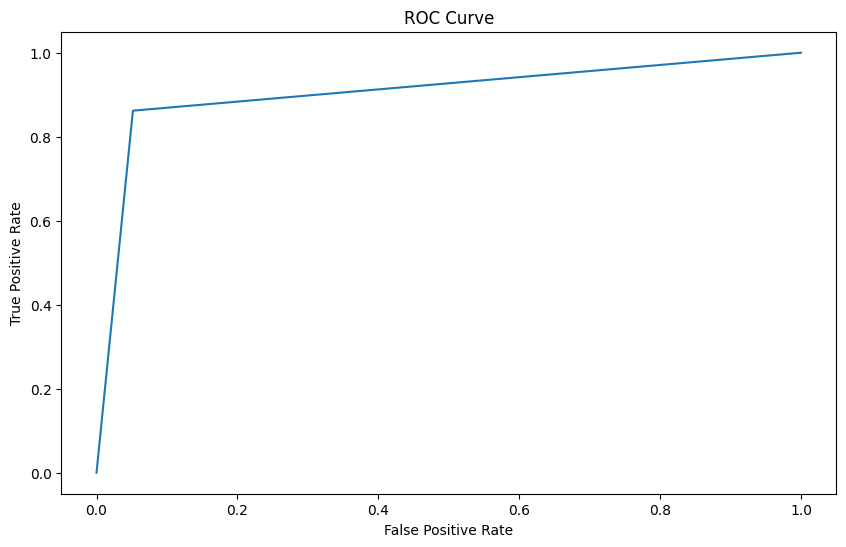

In [8]:
import random
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_curve

with mlflow.start_run(run_name=f"mlops-notebook-classification-run-{random.randint(1,10)}"):
    features = ["Pregnancies", "PlasmaGlucose", "DiastolicBloodPressure", "TricepsThickness", 
    "SerumInsulin", "BMI", "DiabetesPedigree", "Age"]

    X = df[features].values
    y = df[["Diabetic"]].values

    mlflow.log_param("Algorithm", "Random Forest Classifier")
    mlflow.log_param("Dataset size", len(df))
    mlflow.log_param("Train size", "70%")
    mlflow.log_param("Seed", 42)
    X_train, X_test, y_train, y_test = train_test_split(
        X,y, 
        test_size=0.3,
        random_state=42,
        stratify=y,
        shuffle=True
    )

    model = RandomForestClassifier(
        n_estimators=3,
        min_samples_split=4,
        min_samples_leaf=5
    )

    model.fit(X_train, y_train)

    from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_curve

    y_predict = model.predict(X_test)
    mlflow.log_metric("Accuracy", accuracy_score(y_test, y_predict))
    mlflow.log_metric("Recall", recall_score(y_test, y_predict))
    mlflow.log_metric("F1-score", f1_score(y_test, y_predict))

    fpr, tpr, _ = roc_curve(y_test, y_predict, pos_label=1)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.savefig("roc_curve.png")
    mlflow.log_artifact("roc_curve.png")